# House Price Prediction

## Project Overview

This project uses the Ames Housing dataset from Kaggle to analyze the factors that influence residential home prices and build a machine learning model to predict sale prices.

The analysis focuses on data cleaning, exploratory data analysis, feature relationships, model development, evaluation, and final predictions using the original Kaggle test dataset.

 Problem Statement

The goal of this project is to predict residential home sale prices based on property characteristics.

The analysis will identify which features are most strongly associated with sale price and evaluate machine learning models to determine which provides the best predictions.

# =========================
# 1. Import Libraries
# =========================

We import necessary libraries for data manipulation, visualization, and machine learning:

*   **pandas** for data manipulation and analysis.
*   **numpy** for numerical operations.
*   **seaborn** and **matplotlib.pyplot** for data visualization.
*   **sklearn.model_selection.train_test_split** for splitting data into training and testing sets.
*   **sklearn.linear_model.LinearRegression** for implementing the Linear Regression model.
*   **sklearn.ensemble.RandomForestRegressor** for implementing the Random Forest Regression model.
*   **sklearn.metrics.mean_squared_error** for evaluating model performance.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# =========================
# 2. Load Data
# =========================
The Kaggle dataset contains two primary files:

- `train.csv` — contains property information and the target variable, `SalePrice`
- `test.csv` — contains property information but does not include `SalePrice`

The training dataset will be used to develop and evaluate the models. The original test dataset will be reserved for generating final predictions.

In [2]:
import pandas as pd
train = pd.read_csv('train.csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
import pandas as pd
test = pd.read_csv('test.csv')
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


# =========================
# 3. Data Overview
# =========================
Before beginning the analysis, we examine the structure of the training and test datasets, including their dimensions, columns, data types, and missing values.

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [7]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# =========================
# 4. Sale Price Distribution
# =========================
The target variable, `SalePrice`, represents the final sale price of each home.

Understanding its distribution helps identify the typical price range and determine whether the data contains extreme values or significant skewness.

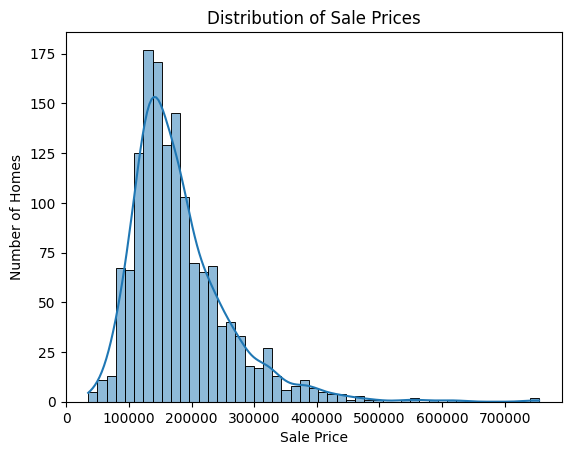

In [8]:
sns.histplot(train["SalePrice"], kde=True)
plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Homes")
plt.show()

# ========================
# 5. Data Cleaning
# ========================

The dataset contains missing values across several features. Missing values will be handled appropriately before the data is used for modeling.

Categorical variables will also be converted into numerical variables so they can be used by machine learning algorithms.

In [9]:
# Fill missing numeric values with median
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
train[numeric_cols] = train[numeric_cols].fillna(train[numeric_cols].median())

# Convert categorical variables
train = pd.get_dummies(train, drop_first=True)
train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


# =========================
# 6. Exploratory Data Analysis
# =========================
Exploratory data analysis is used to identify relationships between property characteristics and sale prices.

The analysis focuses on features such as living area, overall quality, and other characteristics that may influence a home's value.

Text(0.5, 1.0, 'Scatter plot\n Ground Living Area vs Sale Price')

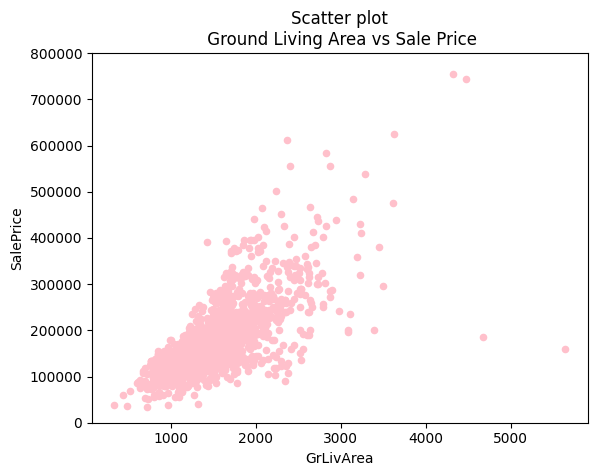

In [10]:
#scatter plot grlivarea/saleprice
data = pd.concat([train['SalePrice'], train['GrLivArea']], axis=1)
data.plot.scatter(x = 'GrLivArea', y ='SalePrice', ylim = (0,800000), color = 'pink');
plt.title('Scatter plot\n Ground Living Area vs Sale Price')

Text(0.5, 1.0, 'Scatter plot\n Overall Quality vs Sale Price')

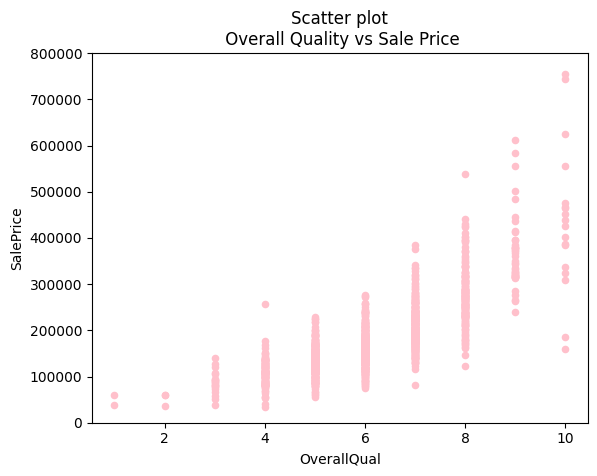

In [11]:
#scatter plot overallqual/saleprice
data = pd.concat([train['SalePrice'], train['OverallQual']], axis=1)
data.plot.scatter(x = 'OverallQual', y ='SalePrice', ylim = (0,800000), color = 'pink');
plt.title('Scatter plot\n Overall Quality vs Sale Price')

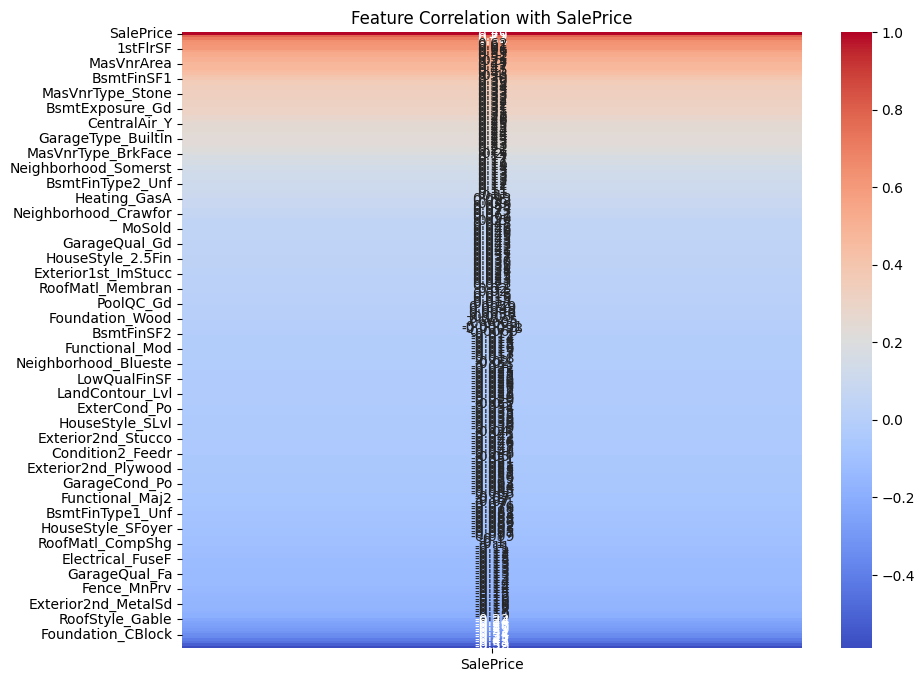

In [12]:
corr = train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['SalePrice']].sort_values(by='SalePrice', ascending=False), annot=True, cmap='coolwarm')
plt.title("Feature Correlation with SalePrice")
plt.show()

# =========================
# 7. Key Feature Relationships
# =========================
This section examines the relationships between important property characteristics and sale price.

Understanding these relationships helps identify potential predictors of housing prices before building the machine learning models.

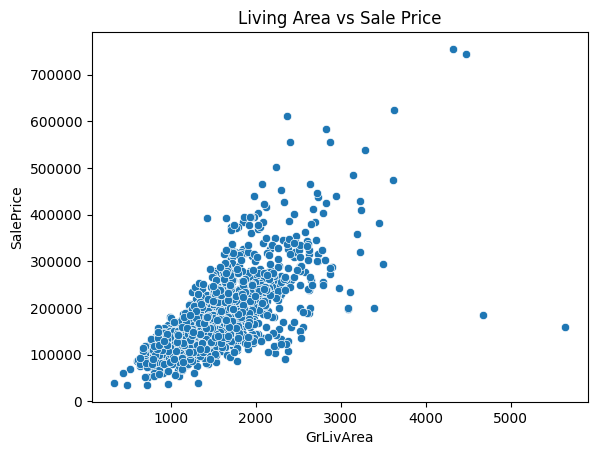

In [13]:
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train)
plt.title("Living Area vs Sale Price")
plt.show()

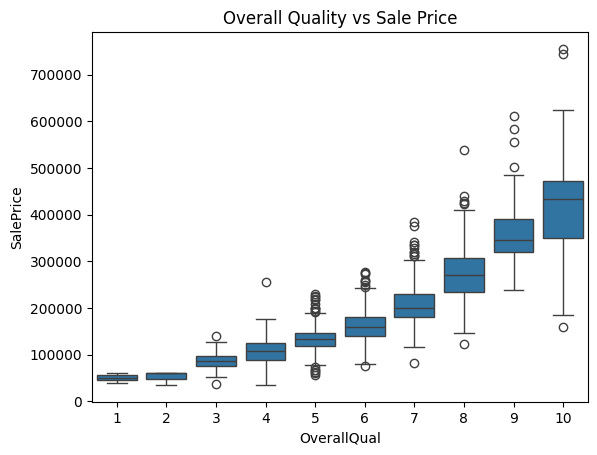

In [14]:
sns.boxplot(x='OverallQual', y='SalePrice', data=train)
plt.title("Overall Quality vs Sale Price")
plt.show()

### Key Insights

- Homes with larger living areas tend to have higher sale prices
- Overall quality shows a strong positive relationship with price
- Higher-quality homes consistently sell for more

These features appear to be strong predictors and will likely improve model performance.

# =========================
# 8. Feature Selection
# =========================
The target variable, `SalePrice`, is separated from the remaining property characteristics.

The remaining variables will be used as input features for the machine learning models.

In [15]:
X = train.drop('SalePrice', axis=1)
y = train['SalePrice']

# =========================
# 9. Train/Test Split
# =========================
The Kaggle training dataset is divided into training and validation sets.

The training set is used to build the models, while the validation set is used to evaluate how well the models perform on unseen data.

The original Kaggle `test.csv` remains separate and will be used only for final predictions.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =========================
# 10. Model Building
# =========================
Two regression models will be developed and compared:

1. Linear Regression
2. Random Forest Regression

Comparing multiple models allows us to determine which approach provides better predictive performance.

In [17]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# =========================
# 11. Model Evaluation
# =========================
The models are evaluated using Root Mean Squared Error (RMSE).

A lower RMSE indicates that the model's predictions are closer to the actual sale prices.

In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Linear Regression RMSE:", rmse(y_test, lr_preds))
print("Random Forest RMSE:", rmse(y_test, rf_preds))

Linear Regression RMSE: 49289.186669387775
Random Forest RMSE: 29019.18277425443


# ======================
# 12. Model Comparison
# ======================
The performance of the Linear Regression and Random Forest models is compared using RMSE.

The model with the lower RMSE will be selected as the preferred model for generating predictions on the original Kaggle test dataset.

In [19]:
print(f"Linear Regression RMSE: {rmse(y_test, lr_preds):.2f}")
print(f"Random Forest RMSE: {rmse(y_test, rf_preds):.2f}")

if rmse(y_test, lr_preds) < rmse(y_test, rf_preds):
    print("\nLinear Regression performed better with a lower RMSE.")
else:
    print("\nRandom Forest performed better with a lower RMSE.")

Linear Regression RMSE: 49289.19
Random Forest RMSE: 29019.18

Random Forest performed better with a lower RMSE.


# =========================
# 13. Feature Importance
# =========================
Feature importance is examined using the Random Forest model to identify which property characteristics contribute most strongly to the model's predictions.

These results provide additional insight into the factors associated with housing prices.

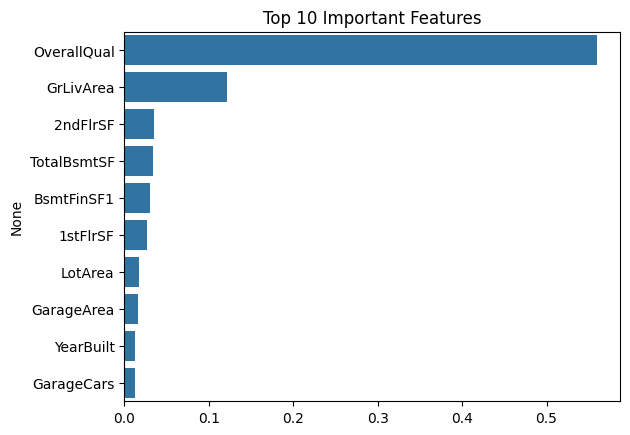

In [20]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 10 Important Features")
plt.show()

# =====================
# 14. Final Predictions
# =====================
After selecting the best-performing model, it is used to generate predictions for the original Kaggle test dataset.

Because the original test dataset does not contain `SalePrice`, these predictions represent the model's estimates for previously unseen properties.

In [21]:
test_copy = test.copy()

# Fill missing numeric values with median (using train data's median to avoid data leakage)
numeric_cols_test = test_copy.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols_test:
    if test_copy[col].isnull().any():
        median_val = train[col].median() if col in train.columns else test_copy[col].median()
        test_copy[col] = test_copy[col].fillna(median_val)

# Convert categorical variables
test_processed = pd.get_dummies(test_copy, drop_first=True)

# Align columns - crucial for consistent feature set between train and test
train_cols = X_train.columns
test_cols = test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    test_processed[c] = 0

# Drop columns in test that are not in train
extra_in_test = set(test_cols) - set(train_cols)
test_processed = test_processed.drop(columns=list(extra_in_test))

# Ensure the order of columns is the same
test_processed = test_processed[train_cols]


In [22]:
# Generate predictions using the best model (Random Forest)
final_predictions = rf.predict(test_processed)

# Create a submission DataFrame
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_predictions
})

display(submission.head())

,Id,SalePrice
0,1461,130516.33
1,1462,153780.00
2,1463,179259.53
3,1464,188772.22
4,1465,205680.84


# ======================
# 15. Prediction Results
# ======================
The predicted sale prices are combined with the corresponding property IDs to create a final prediction dataset.

This output can be used to evaluate the model through the Kaggle competition or demonstrate the model's ability to generate predictions on unseen data.

# =========================
# 16. Conclusion
# =========================
This project analyzed the Ames Housing dataset to identify factors associated with residential home prices and develop a machine learning model for price prediction.

The analysis found that property characteristics such as overall quality and living area are important predictors of sale price.

After comparing multiple regression models, the best-performing model was selected based on RMSE and used to generate predictions for the original Kaggle test dataset.

The project demonstrates a complete data analysis workflow, including data cleaning, exploratory analysis, visualization, machine learning, model evaluation, and prediction.